<h1>Case Técnico — Ciência de Dados</h1>


[Sistema de Recomendação de Produtos Financeiros II](https://github.com/iamsamucoding/case-sistema-recomendacao-II)

Por Beatriz Ottoboni

O objetivo desse trabalho é construir um sistema de recomendação, com o rankeamento de produtos por cliente. O foco está nos 5 primeiros produtos que aparecem para o cliente, que aparecem no scroll dentro do aplicativo.

<b><h2>Sumário</h2></b>
<h4><a href='#eda'>1. Exploratory Data Analysis (EDA)</a></h4>
<h4><a href='#tratamento'>2. Tratamento de Dados e Feature Engineering</a></h4>
<h4><a href='#modelagem'>3. Modelagem</a></h4>
<h4><a href='#avaliacao'>4. Avaliação</a></h4>
<h4><a href='#producao'>5. Proposta de Produção e Próximos Passos</a></h4>

<a id='eda'></a><h3>1. Exploratory Data Analysis (EDA)

1.1. Bibliotecas e requirements

Versoes bibliotecas<br>
pandas==2.2.2<br>
numpy==2.0.2<br>
matplotlib==3.10.0<br>
seaborn==0.13.2<br>
sklearn==1.6.1<br>
tensorflow==2.20.0<br>
shap==0.51.0

As especificações de hardware utilizadas para treinamento e predição foram Intel(R) Xeon(R) CPU @ 2.20GHz com NVIDIA A100-SXM4, CUDA version 13.0 e Python version 3.12.13.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import ndcg_score

import tensorflow as tf

import shap

import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 500)

In [ ]:
# Fixar a seed aleatória para garantir a reprodutibilidade do código
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'


1.2. Definição de funções

In [ ]:
# a funcao cartesiano gera uma matriz com a combinação de cada linha da matriz 1 com todas as linhas da matriz 2
def cartesiano(df_1, df_2):
    df_1['key'] = 1
    df_2['key'] = 1
    df_cart = df_1.merge(df_2, on='key').drop('key', axis=1)
    return df_cart

# Função de erro - Precision@K
def precision_at_k(df, k):
    top_k = df[(df['posicao'] <= k)]
    top_k = top_k.groupby('id_cliente')['contratou'].sum().reset_index()
    top_k['precision_k'] = top_k['contratou'] / k
    return top_k['precision_k'].mean()

# Função de erro - NDCG@K
def ndcg_at_k(df, k):
    ndcg_results = []
    for cliente in df['id_cliente'].unique():
        top_k = df[(df['posicao']<=5) & (df['id_cliente']==cliente)].sort_values(by='posicao', ascending=False)

        y_true  = [top_k['contratou'].tolist()]
        y_score = [top_k['posicao'].apply(lambda r: 1/r).tolist()]

        score = ndcg_score(y_true, y_score)
        ndcg_results.append(score)

    return np.mean(ndcg_results)

# Função de erro - Recall@K
def recall_at_k_micro(df, k=5):
    top_k = df[df['posicao'] <= k]
    total_acertos = ((top_k['contratou'] == 1)).sum()
    total_contratados = df[df['contratou'] == 1]['id_cliente'].count()
    return total_acertos / total_contratados


1.3. Leitura datsets

In [ ]:
clientes = pd.read_csv('https://raw.githubusercontent.com/iamsamucoding/case-sistema-recomendacao-II/refs/heads/main/data/clientes.csv', sep=',')
contratos_ativos = pd.read_csv('https://raw.githubusercontent.com/iamsamucoding/case-sistema-recomendacao-II/refs/heads/main/data/contratos_ativos.csv', sep=',')
interacoes = pd.read_csv('https://raw.githubusercontent.com/iamsamucoding/case-sistema-recomendacao-II/refs/heads/main/data/interacoes.csv', sep=',')
produtos = pd.read_csv('https://raw.githubusercontent.com/iamsamucoding/case-sistema-recomendacao-II/refs/heads/main/data/produtos.csv', sep=',')

1.1. Dataset Clientes

O objetivo dessa etapa é entender a composição do dataset Clientes. O dataset possui 50.000 mil linhas, sendo uma linha por cliente. Há dados faltantes na base. O describe() mostra a distribuição dos dados e nota-se que alguns dados são bastante esparsos, com valores máximos consideravelmente superiores ao percentil 0.99, o que indica que há outliers no dataset.<br>
O Gráfico 1 mostra a matriz de correlação linear entre as variáveis numéricas dos clientes, a diagonal da matriz (que vale 1) foi zerada para melhorar a visualização. Nota-se que a renda_mensal do cliente tem uma correlação muito forte com a qtd\_transacoes\_pix\_6m, assim como vlr\_medio\_gasto\_cartao é altamente correlacionado com vlr\_medio\_gasto\_alimentacao, vlr\_medio\_gasto\_transporte, vlr\_medio\_gasto\_saude e vlr\_medio\_gasto\_lazer. A variável que menos se correlaciona com as outras é a qtd\_dias\_inatividade.<br>
As tabelas abaixo mostram ainda que o canal que mais concentra clientes é o app e que o segmento mais representativo é o basico.

In [ ]:
display(clientes.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_cliente                   50000 non-null  int64  
 1   idade                        50000 non-null  int64  
 2   genero                       50000 non-null  object 
 3   uf                           50000 non-null  object 
 4   segmento                     50000 non-null  object 
 5   score_credito                48448 non-null  float64
 6   renda_mensal                 48499 non-null  float64
 7   saldo_medio_conta            50000 non-null  float64
 8   qtd_meses_cliente            50000 non-null  int64  
 9   qtd_produtos_ativos          50000 non-null  int64  
 10  qtd_transacoes_pix_6m        50000 non-null  int64  
 11  vlr_total_investimentos      48561 non-null  float64
 12  vlr_medio_gasto_cartao       50000 non-null  float64
 13  vlr_medio_gasto_

None

In [ ]:
clientes.head()

,id_cliente,idade,genero,uf,segmento,score_credito,renda_mensal,saldo_medio_conta,qtd_meses_cliente,qtd_produtos_ativos,qtd_transacoes_pix_6m,vlr_total_investimentos,vlr_medio_gasto_cartao,vlr_medio_gasto_alimentacao,vlr_medio_gasto_transporte,vlr_medio_gasto_saude,vlr_medio_gasto_educacao,vlr_medio_gasto_lazer,ind_debito_automatico,qtd_dias_inatividade,vlr_limite_credito,pct_utilizacao_limite,canal_preferencial
0,1,34,F,PR,basico,617.21,1500.00,2981.16,17,0,2,NaN,626.54,97.96,139.06,38.89,35.88,114.53,1,12.0,725.95,0.2062,agencia
1,2,58,F,SP,premium,700.98,16620.77,41901.11,21,8,36,120463.82,3908.82,705.43,679.74,487.83,147.66,415.77,0,6.0,14116.66,0.1795,web
2,3,46,F,AM,intermediario,696.96,4202.55,916.78,57,2,5,0.00,2233.98,795.14,239.72,69.56,245.75,357.10,1,8.0,4414.47,0.4499,app
3,4,31,M,RS,intermediario,611.78,5969.66,10472.53,58,0,8,2741.29,2777.27,704.23,582.83,182.11,21.38,520.29,0,3.0,4992.60,0.3728,app
4,5,56,F,MG,basico,233.49,1816.86,1909.79,32,0,3,2996.98,204.49,49.23,36.48,26.78,9.68,19.63,0,0.0,2139.83,0.5960,app


In [ ]:
clientes.describe(percentiles=[0.25, 0.5, 0.75, 0.99])

,id_cliente,idade,score_credito,renda_mensal,saldo_medio_conta,qtd_meses_cliente,qtd_produtos_ativos,qtd_transacoes_pix_6m,vlr_total_investimentos,vlr_medio_gasto_cartao,vlr_medio_gasto_alimentacao,vlr_medio_gasto_transporte,vlr_medio_gasto_saude,vlr_medio_gasto_educacao,vlr_medio_gasto_lazer,ind_debito_automatico,qtd_dias_inatividade,vlr_limite_credito,pct_utilizacao_limite,flag_canal_app,flag_segmento_basico,flag_segmento_premium
count,50000.000000,50000.000000,48448.000000,48499.000000,50000.000000,50000.000000,50000.000000,50000.000000,4.856100e+04,50000.000000,50000.000000,50000.000000,48492.000000,48547.000000,48479.000000,50000.000000,48472.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,25000.500000,38.276660,543.917928,4939.488462,7600.531757,37.756680,2.009380,9.891420,1.227417e+04,1969.868022,542.012247,296.127395,167.444915,117.366687,226.313176,0.350540,11.846633,5103.564543,0.341504,0.549220,0.551480,0.14914
std,14433.901067,11.351267,178.095975,4081.044502,8129.777578,45.108484,1.748346,8.719215,3.819689e+04,1947.935145,575.018453,335.227759,196.116441,149.154678,262.964865,0.477144,19.995771,5689.679388,0.168044,0.497576,0.497348,0.35623
min,1.000000,18.000000,50.000000,1500.000000,150.500000,1.000000,0.000000,0.000000,0.000000e+00,150.920000,23.990000,8.590000,3.340000,0.000000,5.290000,0.000000,0.000000,500.000000,0.001900,0.000000,0.000000,0.00000
25%,12500.750000,30.000000,419.060000,2297.575000,2611.697500,9.000000,1.000000,4.000000,0.000000e+00,782.500000,199.197500,99.567500,53.290000,30.070000,72.850000,0.000000,2.000000,1684.227500,0.214700,0.000000,0.000000,0.00000
50%,25000.500000,38.000000,542.850000,3617.500000,5072.695000,23.000000,2.000000,7.000000,4.472000e+02,1359.305000,362.520000,189.900000,105.415000,70.160000,142.780000,0.000000,5.000000,3077.955000,0.321900,1.000000,1.000000,0.00000
75%,37500.250000,46.000000,675.692500,6218.080000,9597.317500,49.000000,3.000000,13.000000,8.067660e+03,2447.735000,669.737500,364.700000,204.922500,145.165000,279.725000,1.000000,12.000000,6101.360000,0.451100,1.000000,1.000000,0.00000
99%,49500.010000,64.000000,907.547100,21258.765400,39308.227800,220.000000,7.000000,44.000000,1.685985e+05,9729.601800,2839.320300,1671.390500,964.792300,720.255800,1272.471200,1.000000,100.000000,27626.886400,0.775801,1.000000,1.000000,1.00000
max,50000.000000,80.000000,1000.000000,56042.480000,141333.440000,480.000000,13.000000,116.000000,1.588884e+06,31389.140000,10216.520000,6027.210000,3547.970000,2825.510000,4888.040000,1.000000,278.000000,72275.690000,1.000000,1.000000,1.000000,1.00000


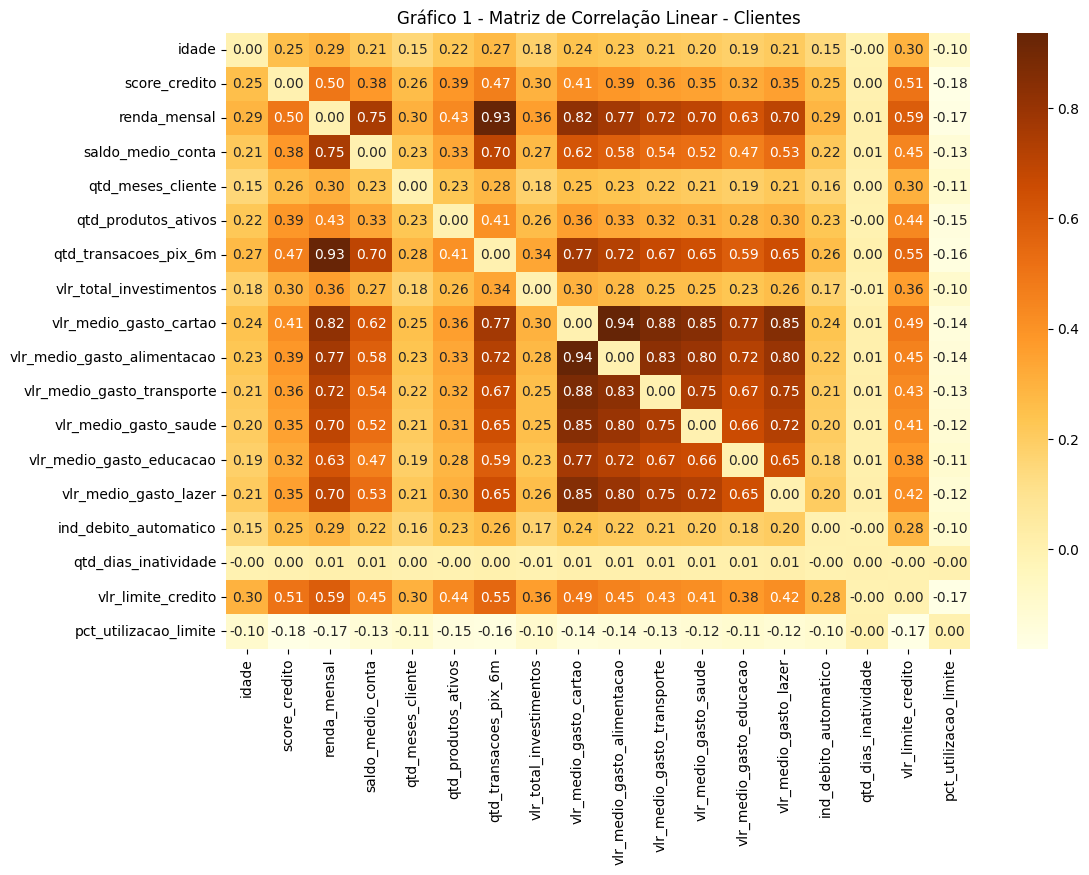

In [ ]:
vars_num = ['idade', 'score_credito',
       'renda_mensal', 'saldo_medio_conta', 'qtd_meses_cliente',
       'qtd_produtos_ativos', 'qtd_transacoes_pix_6m',
       'vlr_total_investimentos', 'vlr_medio_gasto_cartao',
       'vlr_medio_gasto_alimentacao', 'vlr_medio_gasto_transporte',
       'vlr_medio_gasto_saude', 'vlr_medio_gasto_educacao',
       'vlr_medio_gasto_lazer', 'ind_debito_automatico',
       'qtd_dias_inatividade', 'vlr_limite_credito', 'pct_utilizacao_limite']

# Gerar correlações lineares
corr_matrix = clientes[vars_num].corr()
# Zerar diagonal (correlação da variável com ela mesma)
corr_matrix_zero = corr_matrix.mask(np.eye(len(corr_matrix), dtype=bool), 0)

# Gerar gráfico com mapa de calor das correlações
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix_zero, annot=True, cmap='YlOrBr', fmt=".2f")
plt.title("Gráfico 1 - Matriz de Correlação Linear - Clientes")
plt.show()

In [ ]:
(clientes
  .groupby('canal_preferencial')
  .size()
  .sort_values(ascending=False))

,0
canal_preferencial,
app,27461
web,9887
agencia,7510
telefone,5142


In [ ]:
(clientes
  .groupby('segmento')
  .size()
  .sort_values(ascending=False))

,0
segmento,
basico,27574
intermediario,14969
premium,7457


1.2. Dataset produtos

O dataset de produtos tem uma listagem de cada produto, não há valores nulos. Há informações sobre a categoria, a receita e o custo de cada produto. A receita e a margem variam com cada produto. A tabela ordenada por margem mostra que os produtos da categoria investimento concentram as maiores margens.

In [ ]:
produtos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   produto          20 non-null     object 
 1   categoria        20 non-null     object 
 2   receita_media    20 non-null     float64
 3   custo_aquisicao  20 non-null     float64
 4   margem           20 non-null     float64
 5   publico_alvo     20 non-null     object 
dtypes: float64(3), object(3)
memory usage: 1.1+ KB


In [ ]:
(produtos
  .sort_values(by='margem', ascending=False))

,produto,categoria,receita_media,custo_aquisicao,margem,publico_alvo
10,tesouro_direto,investimento,70.0,8.0,0.89,Clientes que buscam investimento seguro com li...
7,investimento_cdb,investimento,95.0,10.0,0.89,Clientes com capital disponivel para investime...
16,consorcio_imovel,consorcio,450.0,55.0,0.88,Clientes que desejam adquirir imovel de forma ...
8,investimento_lci_lca,investimento,110.0,14.0,0.87,Clientes com perfil investidor que buscam isen...
9,previdencia,investimento,150.0,20.0,0.87,Clientes com visao de longo prazo e capacidade...
4,cheque_especial,credito,90.0,12.0,0.87,Clientes que precisam de credito emergencial d...
11,seguro_vida,seguro,85.0,12.0,0.86,"Clientes com dependentes, preocupados com prot..."
5,uso_lastro_limite,credito,35.0,5.0,0.86,Clientes com investimentos que desejam aumenta...
15,consorcio_auto,consorcio,320.0,45.0,0.86,Clientes que desejam adquirir veiculo de forma...
19,portabilidade_salario,conta,20.0,3.0,0.85,Clientes com conta salario em outro banco


1.3. Dataset contratos_ativos

O dataset de contratos ativos apresenta os produtos contratados por cliente que estão ativos, cancelados ou vencidos, junto a data e o canal de contratação. O canal de contratação mais comum é o app, seguido da web e de agencia. Os três produtos mais contratados são conta_digital_plus, credito_pessoal e cartao_platinum e os três menos contratados são titulo_capitalizacao, cartao_black e uso_lastro_limite.

In [ ]:
contratos_ativos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61997 entries, 0 to 61996
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_cliente         61997 non-null  int64 
 1   produto            61997 non-null  object
 2   data_contratacao   61997 non-null  object
 3   status             61997 non-null  object
 4   canal_contratacao  61997 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.4+ MB


In [ ]:
contratos_ativos.head()

,id_cliente,produto,data_contratacao,status,canal_contratacao
0,1,previdencia,2025-10-23,ativo,app
1,4,seguro_residencial,2025-10-26,cancelado,app
2,4,conta_digital_plus,2025-03-25,ativo,app
3,5,credito_consignado,2024-08-08,ativo,agencia
4,5,cheque_especial,2025-09-04,ativo,app


In [ ]:
contratos_ativos['status'].unique()

array(['ativo', 'cancelado', 'vencido'], dtype=object)

In [ ]:
contratos_ativos['canal_contratacao'].unique()

array(['app', 'agencia', 'web', 'telemarketing'], dtype=object)

In [ ]:
(contratos_ativos
  .groupby('canal_contratacao')
  .size()
  .sort_values(ascending=False))

,0
canal_contratacao,
app,27996
web,15367
agencia,12433
telemarketing,6201


In [ ]:
temp = (contratos_ativos
  .groupby('produto')
  .size()
  .rename('proporcao_contratos')
  .sort_values(ascending=False))
# transformar contagem em percentual de todos os contratos
temp = round(temp.div(temp.sum(), axis=0),3) * 100
display(temp)

,proporcao_contratos
produto,
conta_digital_plus,15.8
credito_pessoal,15.0
cartao_platinum,9.1
cheque_especial,9.0
pix_parcelado,7.0
investimento_cdb,6.5
seguro_vida,6.5
seguro_auto,5.4
previdencia,5.1


In [ ]:
temp = (contratos_ativos
  .groupby(['produto', 'canal_contratacao'])
  .size()
  .unstack(fill_value=0))
# transformar contagem em percentual de contratos por produto
temp = round(temp.div(temp.sum(axis=1), axis=0),3) * 100
display(temp)

canal_contratacao,agencia,app,telemarketing,web
produto,,,,
cartao_black,16.8,46.9,7.9,28.4
cartao_platinum,19.7,44.8,9.9,25.6
cheque_especial,19.1,45.2,10.3,25.4
consorcio_auto,19.3,45.6,8.6,26.5
consorcio_imovel,20.3,46.1,8.8,24.7
conta_digital_plus,20.2,45.2,10.0,24.6
credito_consignado,20.7,46.2,8.6,24.5
credito_pessoal,20.4,45.3,10.2,24.2
investimento_cdb,19.7,46.2,9.2,24.9


1.4. Dataset interacoes

O dataset apresenta as interações dos clientes com os produtos ao longo do tempo em cliques e em contratações. Os produtos com a maior geração de receita não são necessariamente os produtos com a maior quantidade de contratações, já que variam em margem. Não houve contratação para os produtos titulo_capitalizacao e uso_lastro_limite no período analisado, mas houve cliques. O app\_busca é o principal canal de contratação, seguido do app\_home. A quantidade de contratações e cliques variam por safra e o número de contratações por safra é em torno de 190.<br>
O gráfico 2 mostra a evolução das contratações e dos cliques ao longo do período analisado. Nota-se que os produtos com mais cliques são os produtos com o maior número de contratações. Alguns produtos têm um comportamento sazonal, sobretudo o pix_parcelado e a previdencia, com um maior número de contratações no mês de dezembro.

In [ ]:
interacoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503292 entries, 0 to 503291
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id_interacao      503292 non-null  int64  
 1   id_cliente        503292 non-null  int64  
 2   produto           503292 non-null  object 
 3   posicao_exibicao  503292 non-null  int64  
 4   canal             503292 non-null  object 
 5   clicou            503292 non-null  int64  
 6   contratou         503292 non-null  int64  
 7   receita_gerada    503292 non-null  float64
 8   timestamp         503292 non-null  object 
 9   safra             503292 non-null  int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 38.4+ MB


In [ ]:
interacoes.head()

,id_interacao,id_cliente,produto,posicao_exibicao,canal,clicou,contratou,receita_gerada,timestamp,safra
0,1,45719,previdencia,1,push_notification,0,0,0.0,2024-01-22 20:36:00,202401
1,2,46225,conta_digital_plus,1,app_home,0,0,0.0,2024-01-24 14:49:00,202401
2,3,38294,cartao_platinum,5,app_home,0,0,0.0,2024-01-13 10:48:00,202401
3,4,23592,investimento_lci_lca,16,email,0,0,0.0,2024-01-14 14:42:00,202401
4,5,24185,credito_pessoal,17,app_home,0,0,0.0,2024-01-15 11:00:00,202401


In [ ]:
temp = (interacoes
    .groupby('produto')
    .agg({'posicao_exibicao':['mean', 'median'],
          'clicou':['sum', 'mean'],
          'contratou':['sum', 'mean'],
          'receita_gerada':'sum'})
    .reset_index())
temp.columns = ['produto', 'posicao_exibicao_mean', 'posicao_exibicao_median', 'clicou_sum', 'clicou_mean', 'contratou_sum', 'contratou_mean', 'receita_gerada']
temp.sort_values(by='receita_gerada', ascending=False)

,produto,posicao_exibicao_mean,posicao_exibicao_median,clicou_sum,clicou_mean,contratou_sum,contratou_mean,receita_gerada
7,credito_pessoal,6.294594,4.0,11234,0.159470,1261,0.017900,282755.29
5,conta_digital_plus,6.311821,4.0,11381,0.160545,1282,0.018084,40384.18
2,cheque_especial,6.238523,4.0,4213,0.094303,347,0.007767,33604.29
13,seguro_auto,6.314010,4.0,2263,0.097317,211,0.009074,29058.48
12,previdencia,6.317784,4.0,1704,0.075272,169,0.007465,27299.60
1,cartao_platinum,6.328932,4.0,5053,0.141059,518,0.014460,24397.85
8,investimento_cdb,6.338402,4.0,2212,0.076625,177,0.006131,17611.93
3,consorcio_auto,6.334793,4.0,991,0.044279,37,0.001653,12024.54
16,seguro_vida,6.330786,4.0,1869,0.062925,89,0.002996,7961.68
14,seguro_residencial,6.298354,4.0,1086,0.072681,116,0.007763,6740.70


In [ ]:
temp = (interacoes
    .groupby('canal')
    .agg({'clicou':['sum', 'mean'],
          'contratou':['sum', 'mean'],
          'receita_gerada':'sum'})
    .reset_index())
temp.columns = ['canal', 'clicou_sum', 'clicou_mean', 'contratou_sum', 'contratou_mean', 'receita_gerada']
temp.sort_values(by='receita_gerada', ascending=False)

,canal,clicou_sum,clicou_mean,contratou_sum,contratou_mean,receita_gerada
0,app_busca,16758,0.221996,3244,0.042974,365027.69
1,app_home,18428,0.091339,827,0.004099,87444.78
3,push_notification,4589,0.036549,141,0.001123,16772.27
4,web_banking,3280,0.081822,146,0.003642,16656.14
2,email,3974,0.065789,161,0.002665,16137.56


In [ ]:
interacoes.groupby('safra').agg({'clicou':'sum', 'contratou':'sum'})

,clicou,contratou
safra,,
202401,2134,198
202402,1901,175
202403,1883,195
202404,2033,191
202405,2089,197
202406,1894,187
202407,2078,183
202408,2222,219
202409,2026,200


In [ ]:
interacoes.groupby('safra').agg({'clicou':'sum', 'contratou':'sum'}).mean()

,0
clicou,1959.541667
contratou,188.291667


In [ ]:
interacoes_produto = interacoes.copy()
interacoes_produto['data'] = pd.to_datetime(interacoes_produto['timestamp'].str[:10])
interacoes_produto = (interacoes_produto
  .groupby(['data', 'produto', 'canal'])
  .agg({'clicou':'sum', 'contratou':'sum', 'receita_gerada':'sum'})
  .reset_index())

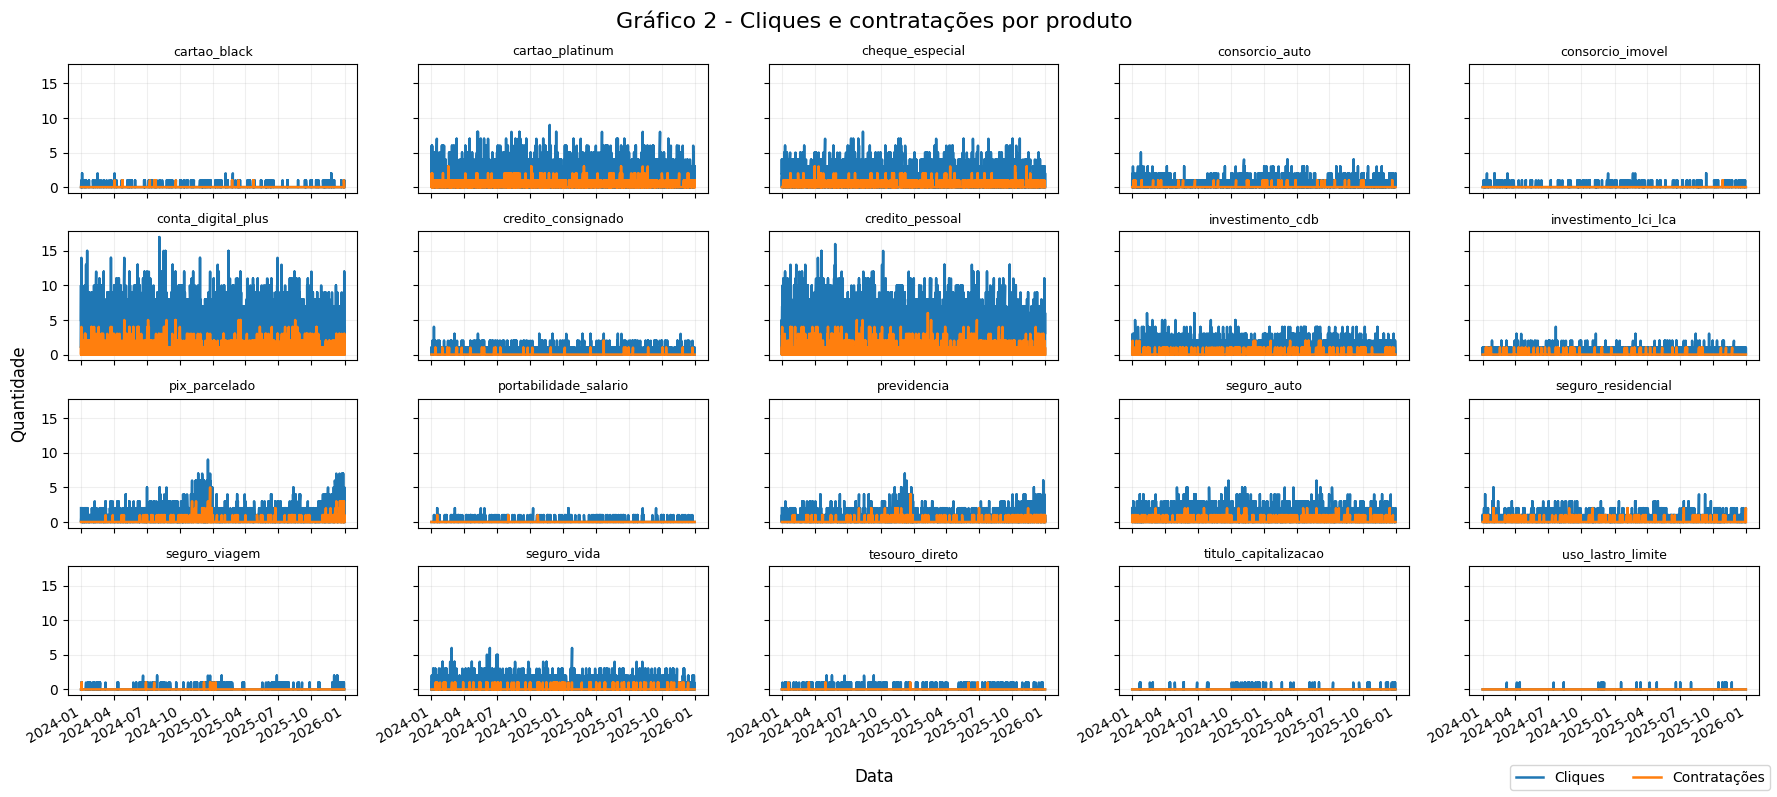

In [ ]:
# criar 20 exibições com os mesmos eixos
fig, axes = plt.subplots(nrows=4,ncols=5,
    figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

# iterar pelos produtos para gerar um gráfico por produto
for ax, produto in zip(axes, interacoes_produto['produto'].unique()):
    d = interacoes_produto[interacoes_produto["produto"] == produto].sort_values("data")

    ax.plot(d["data"], d["clicou"], label="Cliques", linewidth=1.8)
    ax.plot(d["data"], d["contratou"], label="Contratações", linewidth=1.8)

    ax.set_title(produto, fontsize=9)
    ax.grid(True, alpha=0.2)

fig.suptitle("Gráfico 2 - Cliques e contratações por produto", fontsize=16)
fig.supxlabel("Data")
fig.supylabel("Quantidade")
# Filtrar os labels para exibir uma vez
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", ncol=2)
# Formatar exibição da data
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

1.5. Análise das interacoes x clientes

As tabelas a seguir mostram a análise da relação das tabelas interações e clientes. O segmento de clientes com o maior número absoluto de cliques e contratações é o basico, mas o segmento premium é o que possui o maior percentual de contratações. Os clientes com canal preferencial app são os que mais clicam nos produtos.<br>
Os produtos tem um perfil de interações com os clientes diferente, por exemplo, os clientes que contratam seguro_residencial são, em média, mais velhos e possuem uma renda mensal mais alta do que clientes que contratam o seguro viagem.<br>


In [ ]:
temp = interacoes.merge(clientes, on='id_cliente', how='left')

In [ ]:
temp.groupby('segmento').agg({'clicou':['sum', 'mean'], 'contratou':['sum', 'mean']})

clicou           contratou          
                 sum      mean       sum      mean
segmento                                          
basico         24813  0.089276      2377  0.008552
intermediario  12354  0.082138      1090  0.007247
premium         9862  0.131579      1052  0.014036

In [ ]:
temp.groupby('canal_preferencial')['clicou'].mean()

,clicou
canal_preferencial,
agencia,0.086474
app,0.099173
telefone,0.086786
web,0.086250


In [ ]:
temp.groupby('produto').agg({'idade':'mean', 'score_credito':'mean', 'renda_mensal':'mean', 'saldo_medio_conta':'mean',
                             'qtd_meses_cliente':'mean', 'qtd_produtos_ativos':'mean', 'qtd_transacoes_pix_6m':'mean',
                             'vlr_medio_gasto_cartao':'mean', 'vlr_total_investimentos':'mean', 'ind_debito_automatico':'mean',
                             'qtd_dias_inatividade':'mean', 'vlr_limite_credito':'mean', 'qtd_dias_inatividade':'mean', 'pct_utilizacao_limite':'mean'})

,idade,score_credito,renda_mensal,saldo_medio_conta,qtd_meses_cliente,qtd_produtos_ativos,qtd_transacoes_pix_6m,vlr_medio_gasto_cartao,vlr_total_investimentos,ind_debito_automatico,qtd_dias_inatividade,vlr_limite_credito,pct_utilizacao_limite
produto,,,,,,,,,,,,,
cartao_black,39.720586,577.076584,6467.043974,9794.375187,43.904908,2.300191,12.839898,2706.454772,16789.398066,0.409560,12.143082,6514.900906,0.329092
cartao_platinum,40.768327,616.435899,6964.441601,10672.031419,48.984116,2.639886,13.942801,2905.269071,22099.160125,0.464994,11.948191,7697.039558,0.310987
cheque_especial,36.684096,499.974445,3821.385038,5893.199718,31.412692,1.632389,7.654259,1517.269770,6178.581250,0.284768,11.733047,3535.141615,0.353096
consorcio_auto,37.446942,523.667674,4306.748052,6577.894940,35.112685,1.834994,8.640320,1697.463878,8810.951523,0.315312,11.624384,4259.879370,0.349224
consorcio_imovel,38.236148,549.834100,4997.949055,7627.011046,38.507074,2.062711,9.989776,2017.259525,12635.572070,0.357006,11.926522,5270.467369,0.337733
conta_digital_plus,36.940344,512.942468,4095.400830,6357.864129,33.552899,1.736014,8.216222,1621.499185,7493.721383,0.305586,11.757655,3952.727057,0.349181
credito_consignado,36.872563,509.949074,4032.632972,6190.597268,32.817326,1.724281,8.068613,1603.379395,7487.979787,0.299814,11.704567,3876.101661,0.350466
credito_pessoal,36.602603,504.367804,3889.390922,6002.347089,31.944227,1.668001,7.812083,1547.150279,6277.943559,0.288789,11.883289,3651.348040,0.370894
investimento_cdb,39.600319,581.425562,5854.749996,8963.722979,43.350700,2.319177,11.738776,2303.463117,19321.584269,0.409242,11.893329,6466.673600,0.324288


<a id='tratamento'></a><h3>2. Tratamento de Dados e Feature Engineering

O objetivo dessa seção é gerar os datasets que serão usados na modelagem.<br>
Para o dataset de clientes foram criadas as features dummies que indicam se o cliente tem o canal_preferencial igual ao app, e se o cliente é dos segmento basico ou premium. As features qtd_transacoes_pix_6m, vlr_medio_gasto_alimentacao, vlr_medio_gasto_transporte, vlr_medio_gasto_saude,vlr_medio_gasto_educacao e vlr_medio_gasto_lazer foram excluídas devido a alta correlação linear com outras features, conforme apresentado pelo gráfico 1, para evitar o problema de multicolinearidade. As features de genero e uf também foram desconsideradas em um primeiro momento.<br>
Para o dataset de produtos foi criada a variável de receita_media_liq, que representa a receita_media menos o custo_aquisicao, e as variáveis dummies que representam a categoria dos produtos. Foi excluída a variável dummy de capitalizacao gerada pelo encoding devido para evitar o problema de multicolinearidade.<br>
O preenchimento dos dados foi feito com a mediana de cada variável com a função simpleImputer da biblioteca sklearn. A normalização foi feita com a função standardScaler da bibliotaca sklearn que segue a fórmula
$$
z = \frac {x - \mu} {\sigma}
$$
em que $z$ é o valor transformado, $x$ é o valor original, $\mu$ é a média e $\sigma$ é o desvio padrão. Essa normalização calcula a quantidade de desvios padrão existem entre a observação e a média, o que evita problemas com outliers.<br>
Depois os dados são normalizados para valores entre 0 e 1, com a função MinMaxScaler da biblioteca sklearn, o que garante valores positivos e dentro de uma mesma escala.

2.1. Tratamento dataset clientes

In [ ]:
# Criação de features
clientes['flag_canal_app'] = np.where(clientes['canal_preferencial']=='app', 1, 0)
clientes['flag_segmento_basico'] = np.where(clientes['segmento']=='basico', 1, 0)
clientes['flag_segmento_premium'] = np.where(clientes['segmento']=='premium', 1, 0)

# Seleção de features
features = ['score_credito', 'renda_mensal', 'saldo_medio_conta', 'qtd_meses_cliente', 'qtd_produtos_ativos',
            'vlr_medio_gasto_cartao', 'vlr_total_investimentos', 'ind_debito_automatico',
            'qtd_dias_inatividade', 'vlr_limite_credito', 'idade', 'pct_utilizacao_limite',
            'flag_canal_app', 'flag_segmento_basico', 'flag_segmento_premium']

clientes_train = clientes[['id_cliente'] + features]
clientes_train = clientes_train.set_index('id_cliente')
display(clientes_train.shape)

# Tratamento de vazios
imputer_clientes = SimpleImputer(strategy='median')
imputer_clientes.fit(clientes_train)
clientes_train = pd.DataFrame(imputer_clientes.transform(clientes_train), index=clientes_train.index, columns=clientes_train.columns)

# Normalização dos dados
norm = StandardScaler()
norm.fit(clientes_train)
clientes_train = pd.DataFrame(norm.transform(clientes_train), index=clientes_train.index, columns=clientes_train.columns)

norm_positivo = MinMaxScaler(feature_range=(0, 1))
norm_positivo.fit(clientes_train)
clientes_train = pd.DataFrame(norm_positivo.transform(clientes_train), index=clientes_train.index, columns=clientes_train.columns)

(50000, 15)

2.2. Tratamento dataset produtos

In [ ]:
produtos_ordenados = np.sort(produtos['produto'])

# Seleção de features
produtos_train = produtos[['produto', 'categoria', 'receita_media', 'custo_aquisicao', 'margem']]
produtos_train['receita_media_liq'] = produtos_train['receita_media'] * produtos_train['margem']

# Criação de features dummies com base na categoria do produto (ordenar produtos para pegar a ordem em que são geradas as features dummies)
produtos_train.sort_values(by='categoria', inplace=True)
categorias = produtos_train['categoria'].unique()
produtos_train[categorias] = OneHotEncoder(sparse_output=False).fit_transform(produtos_train[['categoria']])
produtos_train.drop(columns=['categoria','capitalizacao'], inplace=True)

produtos_train.sort_values(by='produto', inplace=True)
produtos_train.set_index('produto', inplace=True)
# dicionario de produtos x indices
produto_to_idx = {p: i for i, p in enumerate(produtos_train.index)}

# Normalização dos dados
norm_produtos = StandardScaler()
norm_produtos.fit(produtos_train[['receita_media','margem','custo_aquisicao','receita_media_liq']])
produtos_train[['receita_media','margem','custo_aquisicao','receita_media_liq']] = norm_produtos.transform(produtos_train[['receita_media','margem','custo_aquisicao','receita_media_liq']])

norm_pos_produtos = MinMaxScaler(feature_range=(0, 1))
norm_pos_produtos.fit(produtos_train[['receita_media','margem','custo_aquisicao','receita_media_liq']])
produtos_train[['receita_media','margem','custo_aquisicao','receita_media_liq']] = norm_pos_produtos.transform(produtos_train[['receita_media','margem','custo_aquisicao','receita_media_liq']])

<a id='modelagem'></a><h3>3. Modelagem

A abordagem escolhida foi semelhante a proposta por Barkan e  Koenigstein [1] no artigo que propõe o Item2Vec, uma metologia que usa um algoritmo de rede neural para a filtragem colaborativa, que recomenda jogos e músicas a partir das interações dos usuários.<br>
O algoritmo cria representações das interações entre usuários e mídias e usa a técnica de amostragem negativa, que seleciona N exemplos de mídias negativas (sem interação) para uma positiva [1].  
O modelo proposto performou melhor do que outras técnicas, sobretudo para mídias menos populares com poucas interações [1]. Isso indica que o modelo é capaz de aprender a representação das mídias, aproximando as que similares e distanciando as demais. Assim, para o objetivo do case, que é identificar os produtos que os clientes são mais propensos a contratar com base em seu perfil e comportamento, a técnica é adequada para as recomendações de produtos.

3.1. Definição de funções

A função \_\_init\_\_ da classe itemtovec faz o embedding dos produtos e da associação entre as interações e as informações dos clientes. A função call_treino calcula os scores para produtos das amostragem positivas e negativas com produto interno entre cada par e a função call faz o cálculo dos scores, após o treinamento, dos embeddings dos clientes e dos produtos e faz o produto entre eles.<br>
O embedding dos clientes e interações é feito com duas camadas de perceptrons totalmente conectadas com função de ativação rectified linear unit (reLU), que pode ser utlizada tanto dados positivos e contínuos quanto para dados categóricos. O embedding dos produtos foi feito com uma camada de perceptrons com a função de ativação reLU.<br>
Para calcular os scores de contratação por produto, é feita multiplicação dos embeddings de clientes contra o de protudos que retorna os score de contratação dos produtos por cliente. A função sigmoid é utilizada para padronização dos scores gerados entre 0 e 1.<p>
A função sample_negatives é usada para montar as amostras de produtos negativos para o dataset de amostragem negativa, para os casos que não há produtos negativos explícitos.<br>
A função get_batch_tensors gera os tensores de produtos negativos e positivos usados nas funções durante o treinamento.<br>
A função compute_loss gera a função de perda (loss) que computa a diferença entre os embeddings dos produtos positivos e dos negativos. A função penaliza quando produtos positivos tem embeddings menores do que produtos negativos.

In [ ]:
class itemtovec(tf.keras.Model):
    def __init__(self, n_produtos, n_features, n_prod_features, embed_dim=32):
        super().__init__()

        # Garantir reprodutibilidade com seed inicial
        init = tf.keras.initializers.GlorotUniform(seed=SEED)

        # Embedding Cliente x Interações
        self.client_emb = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(n_produtos + n_features,)),
            tf.keras.layers.Dense(128, activation='relu', kernel_initializer=init),
            tf.keras.layers.Dense(64, activation='relu', kernel_initializer=init),
            tf.keras.layers.Dense(embed_dim, kernel_initializer=init)
        ])

        # Embedding Produtos
        self.product_emb = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(n_prod_features,)),
            tf.keras.layers.Dense(32, activation='relu', kernel_initializer=init),
            tf.keras.layers.Dense(embed_dim, kernel_initializer=init)
        ])

    def call_treino(self, client_input, product_input_pos, product_input_neg, training=True):

        # Cálculos dos embeddings -> Clientes dimensão (batch, embed_dim) e Produtos dimensão (n_produtos, embed_dim)
        client_embed  = self.client_emb(client_input, training=training)
        product_embed_pos = self.product_emb(product_input_pos, training=training)
        product_embed_neg = self.product_emb(product_input_neg, training=training)

        # Multiplicacao das matrizes de embedding -> relação cliente x produto no espaço latente -> dimensão (batch, n_produtos)
        score_pos = tf.reduce_sum(client_embed * product_embed_pos, axis=1)
        score_neg = tf.reduce_sum(client_embed * product_embed_neg, axis=1)

        return score_pos, score_neg

    # Cálculo dos scores a partir da relação dos produtos com os clientes no espaço latente
    def call(self, client_input, product_input, training=False):

        # Cálculos dos embeddings -> Clientes dimensão (batch, embed_dim) e Produtos dimensão (n_produtos, embed_dim)
        client_embed  = self.client_emb(client_input, training=training)
        product_embed = self.product_emb(product_input, training=training)

        # Multiplicacao das matrizes de embedding -> relação cliente x produto no espaço latente -> dimensão (batch, n_produtos)
        scores = tf.matmul(client_embed, product_embed, transpose_b=True)

        return tf.nn.sigmoid(scores)

def sample_negatives(df_pos, produtos, n_neg_per_pos=1):
    rows = []
    rng = np.random.default_rng(seed=SEED)

    for _, row in df_pos.iterrows():
        negativos = [p for p in produtos if p != row['produto_pos']]
        neg_sample = rng.choice(negativos, size=n_neg_per_pos, replace=False)
        for neg in neg_sample:
            rows.append({'id_cliente': row['id_cliente'],
                         'produto_pos': row['produto_pos'],
                         'produto_neg': neg})
    return pd.DataFrame(rows)

def get_batch_tensors(batch_triplas):
    # Fixar ids dos clientes
    client_ids = batch_triplas['id_cliente'].values
    X_clients = tf.constant(features_train.loc[client_ids].values, dtype=tf.float32)

    # Índices dos produtos positivos e negativos
    idx_pos = batch_triplas['produto_pos']
    idx_neg = batch_triplas['produto_neg']

    X_prod_pos = tf.gather(produtos_matriz, idx_pos)
    X_prod_neg = tf.gather(produtos_matriz, idx_neg)

    return X_clients, X_prod_pos, X_prod_neg


def compute_loss(score_pos, score_neg):
    # Bayesian Personalized Ranking Loss para maximizar a diferença entre score do produto positivo e negativo.

    diff = score_pos - score_neg
    loss = tf.reduce_mean(tf.nn.softplus(-diff))

    return loss

3.2. Definição base de treinamento (clientes e produtos)

A base de features dos clientes considera tanto as informações dos clientes, como renda_media, quanto as interações do cliente com os produtos ao longo do tempo. Tanto os cliques quanto as contratações são contabilizados. Os cliques tem um peso 0,2 e a contratação um peso de 0,8, já que o objetivo é maximizar a contratação dos produtos que aparecem para o cliente. <br>
O dataset de produtos considera as categorias e a receita dos produtos.<br>
As safras escolhidas de treinamento foram de 07/2024 a 06/2025. O período escolhido foi um ano pela baixa volumetria de contratações por safra e, assim, garantir o máximo de produtos com contratações no período.

In [ ]:
# Dataset Clientes x Interações
# Score de interacao com base em cliques e contratações, peso de contratação maior que peso de clique
interacoes['score'] = interacoes['clicou'] * 0.2 + interacoes['contratou'] * 0.8

# Pivotar: linhas = clientes, colunas = produtos
features_train = (interacoes
                .query('safra >= 202407 and safra <= 202506')
                .pivot_table(index='id_cliente', columns='produto', values='score', aggfunc='sum', fill_value=0, dropna=False))

# Setar valor máximo de interações como 1
features_train = features_train.clip(upper=1)
display(features_train.shape)

# Adicionar features de clientes
features_train = pd.concat([features_train, clientes_train], axis=1).fillna(0)
features_train =  features_train[list(produtos_ordenados) + features]
display(features_train.shape)

# Dataset de protudos
produtos_matriz = tf.constant(produtos_train.values, dtype=tf.float32)
product_feature_cols = produtos_train.columns

(49637, 20)

(50000, 35)

3.3. Definição target (amostragem negativa)

O objetivo do treinamento é rankear os produtos para as próximas safras. Então as safras usadas como target são as contratações de 07/2025 e 08/2025.<br>
A base de targets é construída com a abordagem de amostragem negativa, com 4 produtos negativos (não contratados pelos clientes) para 1 positivo. O positivo são somente os produtos contratados. Os negativos explícitos são os produtos que o cliente não clicou que estavam até o ranking 5 para o cliente. Para os casos que não há 4 produtos negativos explícitos, é feita a amostragem aleatória entre os produtos negativos (sem contratação) do cliente.

In [ ]:
# Produtos contratados (positivo)
positivos = (interacoes
    .query('safra >= 202507 and safra <= 202508 and contratou == 1')[['id_cliente', 'produto']]
    .rename(columns={'produto': 'produto_pos'}))

# Produtos exibidos mas não contratados (negativos explicitos)
negativos_explicitos = (interacoes
    .query('safra >= 202507 and safra <= 202508 and contratou == 0 and clicou == 0 and posicao_exibicao <= 5')[['id_cliente', 'produto']]
    .rename(columns={'produto': 'produto_neg'}))

# Montar triplas: para cada positivo, samplear um negativo do mesmo cliente
triplas_neg_explicito = positivos.merge(negativos_explicitos, on='id_cliente')
triplas_neg_explicito['ordem'] = 1

# Se algum cliente não tiver negativo explícito, samplear aleatoriamente
triplas_aleatorio = sample_negatives(positivos, produtos=produtos_ordenados, n_neg_per_pos=4)  # 4 negativos por positivo
triplas_aleatorio['ordem'] = 2

# Manter primeiro os negativos explicitos, depois os selecionados aleatoriamente
triplas = pd.concat([triplas_neg_explicito, triplas_aleatorio])
triplas = triplas.sort_values(['id_cliente', 'produto_pos','ordem'])
triplas['rn'] = triplas.groupby(['id_cliente', 'produto_pos']).cumcount() + 1
triplas = triplas.query('rn < 5').drop(columns=['ordem', 'rn']) # 4 negativos por positivo

triplas['produto_pos'] = [produto_to_idx[p] for p in triplas['produto_pos']]
triplas['produto_neg'] = [produto_to_idx[p] for p in triplas['produto_neg']]

O treinamento gera os embedding com 32 dimensões. O otimizador Adaptive Moment Estimation (Adam) é utilizado para o cálculo do gradiente. Os dados são divididos por batch de clientes de tamanho 64 e rodou em 50 épocas.<br>
O gráfico 3 mostra a função perda por época que apresenta um comportamento de queda até a época 30 e de mais estabilidade a partir dessa época.

In [ ]:
model = itemtovec(
    n_produtos=20,
    n_features=len(features),
    n_prod_features=len(product_feature_cols),
    embed_dim=32
)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Dataset de triplas
triplas_dataset = (tf.data.Dataset
    .from_tensor_slices(dict(triplas))
    .batch(64))

epochs = pd.DataFrame()
for epoch in range(50):
    epoch_loss = 0.0

    for batch in triplas_dataset:

        batch_df = pd.DataFrame({k: v.numpy() for k, v in batch.items()})
        batch_df['id_cliente'] = batch_df['id_cliente'].astype(int)

        X_clients, X_prod_pos, X_prod_neg = get_batch_tensors(batch_df)

        with tf.GradientTape() as tape:

            # Calculo dos scores para produtos positivos e negativos
            score_pos, score_neg = model.call_treino(X_clients, X_prod_pos, X_prod_neg, training=True)

            # Função de perda (diferença entre scores dos produtos positivos e negativos)
            loss = compute_loss(score_pos, score_neg)

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        epoch_loss += loss.numpy()

    epochs = pd.concat([epochs, pd.DataFrame(data={'Epoch':[epoch+1], 'Loss':[epoch_loss]})])
    print(f"Epoch {epoch+1} — Loss: {epoch_loss:.4f}")

Epoch 1 — Loss: 14.1081
Epoch 2 — Loss: 10.0323
Epoch 3 — Loss: 8.2133
Epoch 4 — Loss: 7.3713
Epoch 5 — Loss: 6.8902
Epoch 6 — Loss: 6.5819
Epoch 7 — Loss: 6.3287
Epoch 8 — Loss: 6.1136
Epoch 9 — Loss: 5.9329
Epoch 10 — Loss: 5.7694
Epoch 11 — Loss: 5.6267
Epoch 12 — Loss: 5.4917
Epoch 13 — Loss: 5.3745
Epoch 14 — Loss: 5.2611
Epoch 15 — Loss: 5.1498
Epoch 16 — Loss: 5.0567
Epoch 17 — Loss: 4.9564
Epoch 18 — Loss: 4.8582
Epoch 19 — Loss: 4.7659
Epoch 20 — Loss: 4.6688
Epoch 21 — Loss: 4.5785
Epoch 22 — Loss: 4.4893
Epoch 23 — Loss: 4.3942
Epoch 24 — Loss: 4.3017
Epoch 25 — Loss: 4.2166
Epoch 26 — Loss: 4.1232
Epoch 27 — Loss: 4.0316
Epoch 28 — Loss: 3.9523
Epoch 29 — Loss: 3.8560
Epoch 30 — Loss: 3.7697
Epoch 31 — Loss: 3.6824
Epoch 32 — Loss: 3.5932
Epoch 33 — Loss: 3.5081
Epoch 34 — Loss: 3.4347
Epoch 35 — Loss: 3.3447
Epoch 36 — Loss: 3.2686
Epoch 37 — Loss: 3.1838
Epoch 38 — Loss: 3.1161
Epoch 39 — Loss: 3.0431
Epoch 40 — Loss: 2.9544
Epoch 41 — Loss: 2.8845
Epoch 42 — Loss: 2.7987

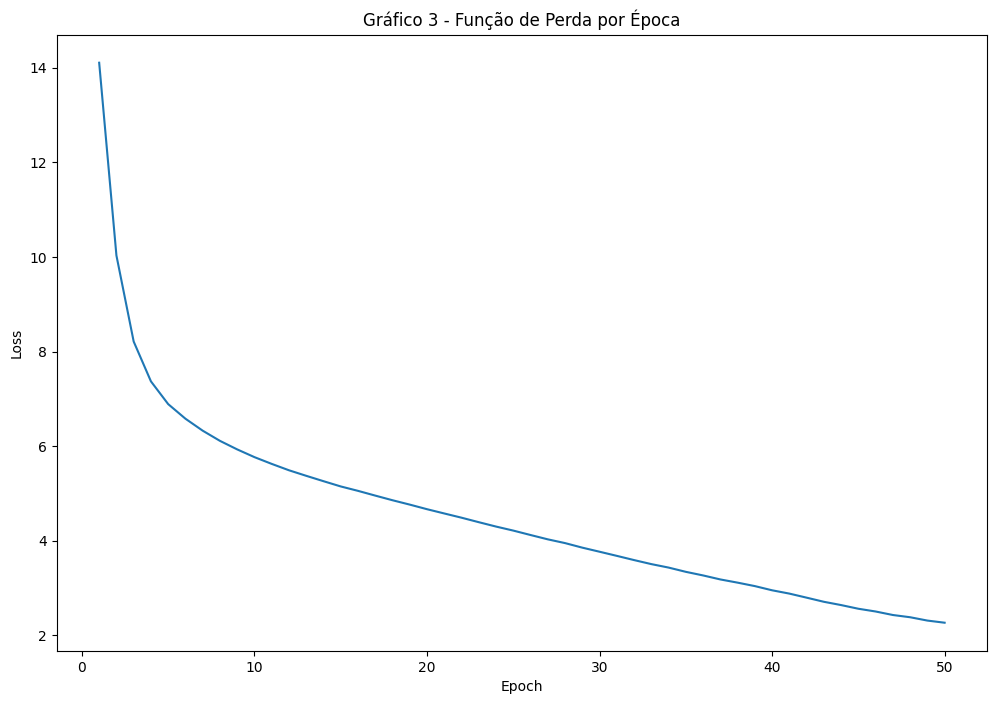

In [ ]:
plt.figure(figsize=(12, 8))
sns.lineplot(data=epochs, x='Epoch', y='Loss')
plt.title("Gráfico 3 - Função de Perda por Época")
plt.show()

3.4. Variáveis mais explicativas

Um desafio com modelos de redes neurais é a explicabilidade, devido às transformações feitas nos dados durante o treinamento e são, por isso, chamados de modelos caixa preta [2]. O SHapley Additive exPlanations (SHAP) é uma ferramenta que pode ser usada para explicar o impacto de variáveis na predição do modelo [2].<br>
Os gráficos 4 e 5 mostram as 10 variáveis mais importantes construídas pelo SHAP. A variável mais importante é a flag\_segmento\_premium, sendo os valores mais altos dessa variável impactam negativamente os scores. A flag\_segmento\_basico, por outro lado, impacta positivamente o score quando tem valores mais altos. Clientes com ind\_debito\_automatico tem impacto positivo nos scores, assim como idade, flag\_canal\_app, renda\_mensal, saldo\_medio\_contra e qtd\_meses\_cliente impactam positivamente o score com os valores mais altos. De outra maneira, o interações com o produto cartao\_platinum e maiores valores de vlr\_limite\_credito e vlr\_medio\_gasto\_cartao impactam negativamente o score.<br>
O SHAP oferece então um panorama do que foi mais importante ao calcular os scores, com as principais variáveis e os seus pesos. Contudo, a visão cliente a cliente do que impactou a decisão entre recomendar um produto em detrimento de outro é pouca clara. Então, mesmo com o SHAP, uma limitação desse modelo é a explicabilidade.

In [ ]:
def scores_shap(client_inputs):
    clientes_shap  = tf.constant(client_inputs, dtype=tf.float32)
    produtos_shap = tf.constant(produtos_matriz, dtype=tf.float32)

    scores = model.call(clientes_shap, produtos_shap, training=False)
    return scores.numpy().sum(axis=1)

background = features_train[:100]
explainer = shap.KernelExplainer(scores_shap, background)
X_explain = features_train[150:200]
feature_names = list(features_train.columns)
shap_values = explainer.shap_values(X_explain)

  0%|          | 0/50 [00:00<?, ?it/s]

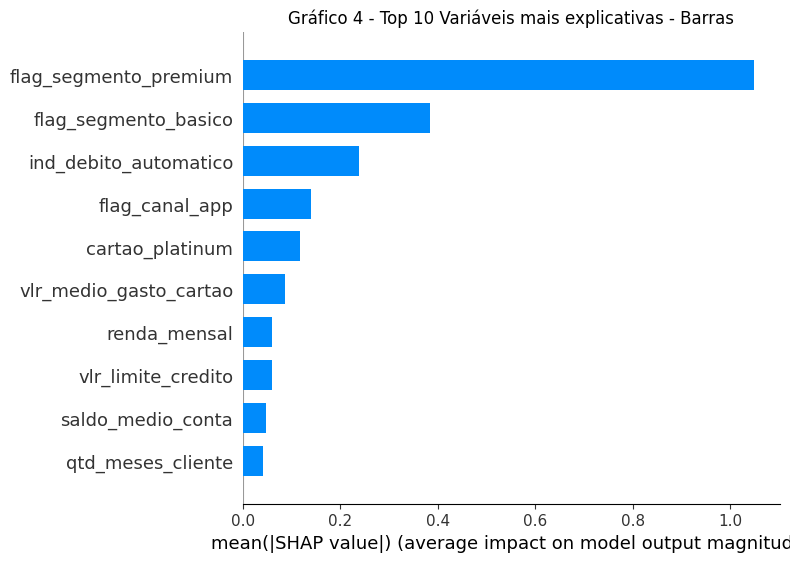

In [ ]:
shap.summary_plot(shap_values, X_explain, feature_names=feature_names, plot_type='bar', show=False, max_display=10)
plt.title('Gráfico 4 - Top 10 Variáveis mais explicativas - Barras')
plt.show()

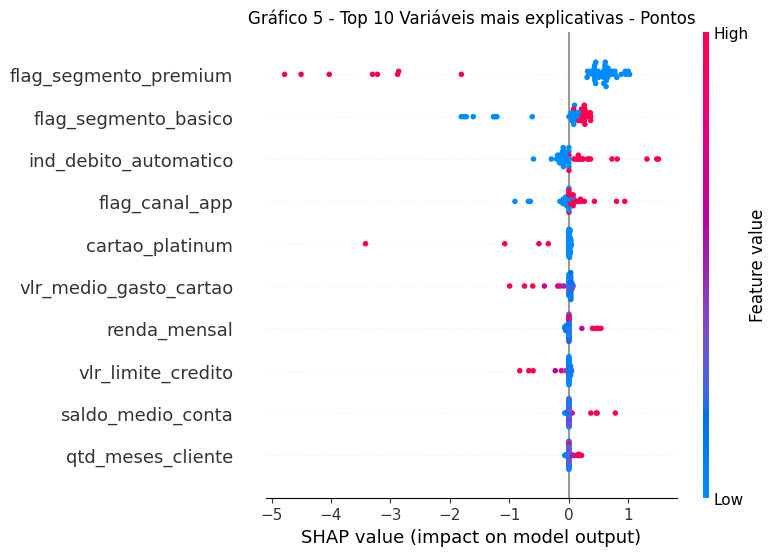

In [ ]:
shap.summary_plot(shap_values, X_explain, feature_names=feature_names, show=False, max_display=10)
plt.title('Gráfico 5 - Top 10 Variáveis mais explicativas - Pontos')
plt.show()

3.4. Verificação do desempenho com dados de treino

As métricas escolhidas para avaliação do desempenho do modelo foram Precision@K, Normalized Discounted Cumulative Gain (NDCG@K) e Recall@K (micro) com K=5, já que os produtos relevantes estão até a quinta posição.<br>
A previsão com os dados de treino tem como objetivo verificar se o modelo consegue, pelo menos para os dados de treino, gerar boas recomendações. No período target do treino, houve 377 contratações, o que representa apenas 0,038% da relação entre clientes e produtos.<br>
Se considerada a base completa, o desempenho do modelo não é bom, conforme o precision@5 e NDCG@5 mostram. Isso se deve a baixa taxa de contratação em relação aos produtos.<br>
Se considerada a relação cliente x produtos apenas para clientes com contratação, o precision@5 vale 0.19, então em torno de 1 dos 5 produtos recomendados para o clientes foi contratado. E o NDCG@5 vale 0.70, o que indica que os produtos contratados estavam nas primeiras posições do rankeamento. Por fim, o recall@5 na visão micro vale 0.95, o que indica que 95% dos produtos contratados estavam dentro dos 5 recomendados. O modelo é capaz de refazer as recomendações para os dados de treinamento.

In [ ]:
contratacoes = (cartesiano(clientes[['id_cliente']], produtos[['produto']]))
display(contratacoes.shape)
contratacoes = (
    contratacoes
      .merge(
          interacoes.query('safra >= 202507 and safra <= 202508 and contratou==1')[['id_cliente', 'produto', 'contratou']].drop_duplicates(keep='first'),
          on=['id_cliente', 'produto'],  how='left'
      )
      .fillna(0)
    )
display(contratacoes.shape)
print(f'Total Contratações no período: {contratacoes['contratou'].sum()}')
print(f'Total Contratações / (Núm. Clientes x Produtos) no período: {round(contratacoes['contratou'].sum()/contratacoes.shape[0]*100,3)}%')

(1000000, 2)

(1000000, 3)

Total Contratações no período: 377.0
Total Contratações / (Núm. Clientes x Produtos) no período: 0.038%


In [ ]:
# Dados de treino (verificar underfitting)

scores = model.call(tf.constant(features_train.values, dtype=tf.float32),
                    produtos_matriz,
                    training=False)

# Montar ranking
scores_df = pd.DataFrame(scores, index=features_train.index, columns=produtos_train.index)

recomendacoes = (scores_df
    .reset_index()
    .melt(id_vars='id_cliente', var_name='produto', value_name='score')
    .merge(contratacoes, on=['id_cliente', 'produto'], how='left'))


recomendacoes['posicao'] = recomendacoes.groupby('id_cliente')['score'].rank(method='first', ascending=False)
recomendacoes['com_contratacao'] = recomendacoes.groupby('id_cliente')['contratou'].transform('sum')


precision_treino = precision_at_k(recomendacoes, k=5)
precision_treino_contratacao = precision_at_k(recomendacoes[recomendacoes['com_contratacao']>0], k=5)
ndcg_treino = ndcg_at_k(recomendacoes, k=5)
ndcg_treino_contratacao = ndcg_at_k(recomendacoes[recomendacoes['com_contratacao']>0], k=5)
recall_treino = recall_at_k_micro(recomendacoes, k=5)

pd.DataFrame(data={'Métrica':['Precision@5', 'Precision@5 (somente com contratação)', 'NDCG@5', 'NDCG@5 (somente com contratação)', 'Recall@5'],
    'Resultado Treino':[precision_treino, precision_treino_contratacao, ndcg_treino, ndcg_treino_contratacao, recall_treino]})

,Métrica,Resultado Treino
0,Precision@5,0.001436
1,Precision@5 (somente com contratação),0.190451
2,NDCG@5,0.005272
3,NDCG@5 (somente com contratação),0.699189
4,Recall@5,0.952255


<h3><a id='avaliacao'></a>4. Avaliação

O período utilizado para teste foram as safras de 04/2025 a 10/2025, com a previsão para as safras de 11/2025 e 12/2025. Para o teste, o período de 6 meses anteriores às safras target foram necessários para a previsão. Uma quatidade menor de safras gerava resultados piores, e mais safras não melhoravam significativamente o resultado.<br>
Antes da avaliação, os produtos com contratos já ativos para os clientes, com data de contratação até 31/10/2025, foram removidos do dataset de teste e do baseline.<br>
Para o baseline foram utilizados os produtos de contratação mais frequente durante o mesmo período do teste. Nesse caso, os scores por produto são os mesmos para todos os clientes, mas a posição pode variar dependendo dos produtos que o cliente tiver ativo.<br>
Assim como no período de treino, a taxa de contratação em relação ao total de clientes e produtos é baixa, de 0,036%, por isso os resultados são avaliados tanto na base completa, quanto em uma base somente com clientes com contratação.

In [ ]:
# Target período de teste
contratacoes_test = (cartesiano(clientes[['id_cliente']], produtos[['produto']]))
display(contratacoes_test.shape)
contratacoes_test = (
    contratacoes_test
      .merge(
          interacoes.query('safra >= 202511 and contratou==1')[['id_cliente', 'produto', 'contratou']].drop_duplicates(keep='first'),
          on=['id_cliente', 'produto'], how='left'
      )
      .fillna(0)
    )
display(contratacoes_test.shape)

print(f'Total Contratações no período: {contratacoes_test["contratou"].sum()}')
print(f'Total Contratações / (Núm. Clientes x Produtos) no período: {round(contratacoes_test['contratou'].sum()/contratacoes_test.shape[0]*100, 3)}%')

(1000000, 2)

(1000000, 3)

Total Contratações no período: 357.0
Total Contratações / (Núm. Clientes x Produtos) no período: 0.036%


In [ ]:
# Contratos já ativos -> não recomendar para o cliente
display(contratos_ativos.shape)
remover = (contratos_ativos[(contratos_ativos['status']=='ativo') & (contratos_ativos['data_contratacao']<'2025-11-01')])
display(remover.shape)
display(remover['data_contratacao'].max())
remover['remover_key'] = 1
remover = remover[['id_cliente', 'produto', 'remover_key']].drop_duplicates(keep='first')
display(remover.shape)

(61997, 5)

(49946, 5)

'2025-10-31'

(49946, 3)

4.1. Inferência - Recomendações teste

In [ ]:
# Dados de teste

features_test = (interacoes
                .query('(safra >= 202504) & (safra <= 202510)')
                .pivot_table(index='id_cliente', columns='produto', values='score', aggfunc='sum', fill_value=0, dropna=False))
features_test = features_test.clip(upper=1)
display(features_test.shape)

features_test = pd.concat([features_test, clientes_train], axis=1).fillna(0)
features_test =  features_test[list(produtos_ordenados) + features]
display(features_test.shape)

scores = model.call(tf.constant(features_test.values, dtype=tf.float32),
                    produtos_matriz,
                    training=False)

# Montar ranking
scores_df = pd.DataFrame(scores, index=features_test.index, columns=produtos_train.index)
display(scores_df.shape)
recomendacoes = (scores_df
    .reset_index()
    .melt(id_vars='id_cliente', var_name='produto', value_name='score')
    .merge(remover, on=['id_cliente', 'produto'], how='left')
    .query('remover_key!=1')
    .drop(columns=['remover_key'])
    .merge(contratacoes_test, on=['id_cliente', 'produto'], how='left')
)
display(recomendacoes.shape)

recomendacoes['posicao'] = recomendacoes.groupby('id_cliente')['score'].rank(method='first', ascending=False)
recomendacoes['com_contratacao'] = recomendacoes.groupby('id_cliente')['contratou'].transform('sum')


(47543, 20)

(50000, 35)

(50000, 20)

(950054, 4)

In [ ]:
# Métricas de erro
precision_teste = precision_at_k(recomendacoes, k=5)
precision_teste_contratacao = precision_at_k(recomendacoes[recomendacoes['com_contratacao']>0], k=5)
ndcg_teste = ndcg_at_k(recomendacoes, k=5)
ndcg_teste_contratacao = ndcg_at_k(recomendacoes[recomendacoes['com_contratacao']>0], k=5)
recall_teste = recall_at_k_micro(recomendacoes, k=5)

In [ ]:
# Dataset de receita gerada com recomendações do teste
receita_recomendacoes = (recomendacoes
                    .query('contratou==1')
                    .merge(produtos, on='produto'))
receita_recomendacoes['receita_media_liq'] = receita_recomendacoes['receita_media'] * receita_recomendacoes['margem']

4.2. Baseline

In [ ]:
produtos_sum = interacoes.query('(safra >= 202505) & (safra <= 202510)').groupby('produto')['contratou'].sum().reset_index()
produtos_sum.sort_values('produto', inplace=True)
produtos_sum['prop_contratacao'] = produtos_sum['contratou'] / produtos_sum['contratou'].sum()
produtos_sum = produtos_sum.merge(produtos, on='produto')
produtos_sum['score'] = produtos_sum['prop_contratacao'] * produtos_sum['margem']
produtos_sum = produtos_sum[['produto', 'score']]

baseline = cartesiano(clientes_train.reset_index()[['id_cliente']], produtos_sum)
baseline = (baseline
            .merge(remover, on=['id_cliente', 'produto'], how='left')
            .query('remover_key!=1')
            .drop(columns=['remover_key'])
            .merge(contratacoes_test, on=['id_cliente', 'produto'], how='left')
)

baseline['posicao'] = baseline.groupby('id_cliente')['score'].rank(method='first', ascending=False)

baseline['com_contratacao'] = baseline.groupby('id_cliente')['contratou'].transform('sum')

display(baseline.head())

,id_cliente,produto,score,contratou,posicao,com_contratacao
0,1,cartao_black,0.000000,0.0,15.0,0.0
1,1,cartao_platinum,0.106554,0.0,3.0,0.0
2,1,cheque_especial,0.063079,0.0,4.0,0.0
3,1,consorcio_auto,0.007288,0.0,11.0,0.0
4,1,consorcio_imovel,0.000829,0.0,14.0,0.0


In [ ]:
# Métricas de erro
precision_baseline = precision_at_k(baseline, k=5)
precision_baseline_contratacao = precision_at_k(baseline[baseline['com_contratacao']>0], k=5)
ndcg_baseline = ndcg_at_k(baseline, k=5)
ndcg_baseline_contratacao = ndcg_at_k(baseline[baseline['com_contratacao']>0], k=5)
recall_baseline = recall_at_k_micro(baseline, k=5)

In [ ]:
# Dataset de receita gerada baseline
receita_baseline = (baseline
                    .query('contratou==1')
                    .merge(produtos, on='produto'))
receita_baseline['receita_media_liq'] = receita_baseline['receita_media'] * receita_baseline['margem']

4.3. Comparação Recomendação Modelo vs Baseline

As tabelas abaixo apresentam os resultados das métricas de erro e a receita gerada (dentro e fora das 5 primeiras posições) para o baseline e para o teste.<br>
O modelo de teste supera baseline em todas as métricas. Com o modelo, a proporção de produtos contratados com recomendação (recall@5) é de 83% enquanto para o baseline é de 70%. O NDCG@5 para o baseline é de 0.51, enquanto para o modelo é de 0.56, o que indica que a ordem do modelo é mais assertiva que o baseline.<br>
A geração de receita também é maior para o modelo, a receita líquida gerada entre dentro das 5 primeiras recomendações é 10,9% maior do que o baseline, o que indica que o ganho financeiro do modelo é maior do que o baseline.<br>
O desempenho do modelo foi pior para o teste, o que pode indicar que há overfitting no modelo, assim para uma próxima versão seria possível testar outras arquiteturas da rede neural, com a inclusão de técnicas de regularização, como DropOut.<br>


In [ ]:
pd.DataFrame(data={'Métrica':['Precision@5', 'Precision@5 (somente com contratação)', 'NDCG@5', 'NDCG@5 (somente com contratação)', 'Recall@5'],
    'Resulato Baseline':[precision_baseline, precision_baseline_contratacao, ndcg_baseline, ndcg_baseline_contratacao, recall_baseline],
    'Resultado Teste':[precision_teste, precision_teste_contratacao, ndcg_teste, ndcg_teste_contratacao, recall_teste]})

,Métrica,Resulato Baseline,Resultado Teste
0,Precision@5,0.001000,0.001184
1,Precision@5 (somente com contratação),0.140056,0.165826
2,NDCG@5,0.003674,0.003985
3,NDCG@5 (somente com contratação),0.514590,0.558115
4,Recall@5,0.700280,0.829132


In [ ]:
pd.DataFrame(
    data={'Métrica Receita':
              ['Receita Total (K<=5)', 'Receita Líquida (K<=5)', 'Custo Total (K<=5)',
                'Receita Total (K>5)', 'Receita Líquida (K>5)', 'Custo Total (K>5)',],
          'Resultados Receita Baseline':
              [receita_baseline.query('posicao<=5')['receita_media'].sum(),  receita_baseline.query('posicao<=5')['receita_media_liq'].sum(), receita_baseline.query('posicao<=5')['custo_aquisicao'].sum(),
               receita_baseline.query('posicao>5')['receita_media'].sum(),  receita_baseline.query('posicao>5')['receita_media_liq'].sum(), receita_baseline.query('posicao>5')['custo_aquisicao'].sum()],
          'Resultados Receita Teste':
              [receita_recomendacoes.query('posicao<=5')['receita_media'].sum(), receita_recomendacoes.query('posicao<=5')['receita_media_liq'].sum(), receita_recomendacoes.query('posicao<=5')['custo_aquisicao'].sum(),
               receita_recomendacoes.query('posicao>5')['receita_media'].sum(), receita_recomendacoes.query('posicao>5')['receita_media_liq'].sum(), receita_recomendacoes.query('posicao>5')['custo_aquisicao'].sum()
               ]})

,Métrica Receita,Resultados Receita Baseline,Resultados Receita Teste
0,Receita Total (K<=5),28255.00,31195.0
1,Receita Líquida (K<=5),23576.15,26152.6
2,Custo Total (K<=5),4611.00,4984.0
3,Receita Total (K>5),8065.00,5125.0
4,Receita Líquida (K>5),6958.25,4381.8
5,Custo Total (K>5),1117.00,744.0


In [ ]:
print(f'Diferença % Receita Líq.: {round(26152.6/23576.15 -1, 4) * 100}%')

Diferença % Receita Líq.: 10.93%


4.4. Previsão para as próximas duas safras

In [ ]:
# Contratos já ativos -> não recomendar para o cliente
display(contratos_ativos.shape)
remover = (contratos_ativos[(contratos_ativos['status']=='ativo')])
display(remover.shape)
display(remover['data_contratacao'].max())
remover['remover_key'] = 1
remover = remover[['id_cliente', 'produto', 'remover_key']].drop_duplicates(keep='first')
display(remover.shape)

(61997, 5)

(54526, 5)

'2025-12-30'

(54526, 3)

In [ ]:
# Dados de Previsão

features_prev = (interacoes
                .query('(safra >= 202506) & (safra <= 202512)')
                .pivot_table(index='id_cliente', columns='produto', values='score', aggfunc='sum', fill_value=0, dropna=False))
features_prev = features_prev.clip(upper=1)
display(features_prev.shape)

features_prev = pd.concat([features_prev, clientes_train], axis=1).fillna(0)
features_prev =  features_prev[list(produtos_ordenados) + features]
display(features_prev.shape)

scores = model.call(tf.constant(features_prev.values, dtype=tf.float32),
                    produtos_matriz,
                    training=False)

# Montar ranking
scores_df = pd.DataFrame(scores, index=features_prev.index, columns=produtos_train.index)
display(scores_df.shape)
recomendacoes_prev = (scores_df
    .reset_index()
    .melt(id_vars='id_cliente', var_name='produto', value_name='score')
    .merge(remover, on=['id_cliente', 'produto'], how='left')
    .query('remover_key!=1')
    .drop(columns=['remover_key'])
)
display(recomendacoes_prev.shape)

recomendacoes_prev['posicao'] = recomendacoes_prev.groupby('id_cliente')['score'].rank(method='first', ascending=False)

(47492, 20)

(50000, 35)

(50000, 20)

(945474, 3)

In [ ]:
path = '.'
arquivo_recomendacoes = recomendacoes[['id_cliente', 'produto', 'posicao', 'score']]
arquivo_recomendacoes.sort_values(['id_cliente','posicao'], inplace=True)
arquivo_recomendacoes.to_csv(f'{path}/recomendacoes.csv', index=False)

<h3><a id='producao'></a>5. Proposta de Produção e Próximos Passos</h3>

5.1. Proposta de Produção

- <b>Implementação</b>: Como a inferência é feita para as duas próximas safras, a implementação deve ser feita em batch, com a previsão para ao final da safra, feita para suas próximas safras.<br>
- <b>Acompanhamento</b>: O acompanhamento do modelo deve ser feito a partir das métricas de erro usadas para a definição do modelo (precision@5, NDCG@5 e Recall@5). Além dessas métricas, é necessário avaliar se a receita gerada com as contratações é maior entre os 5 primeiros produtos recomendados ou para o restante dos produtos, já que o projeto também considera a receita gerada com as contratações.
- <b>Retreino</b>: O retreino deve ser avaliado a cada final de safra com o acompanhamento das métricas de erro e da receita. Caso o modelo perca a performance, como com o NDCG@5 abaixo de 0,5, isso pode indicar que houve uma mudança de comportamento dos clientes e, por isso, o retreino é necessário. Em um primeiro momento o retreino pode ser feito a cada seis meses, caso as métricas de erro se mantenham estáveis.

5.2. Próximos Passos

- Testar  outras abordagens de geração de score para avaliar de modelo item2Vec ainda performa melhor, como cálculo de otimização para maximizar receita;
- Testar técnicas de regularização para melhorar a performance do modelo nos dados de teste, como o DropOut;
- Testar outras arquiteturas e técnicas de otmização de parâmetros automática, como o optuna.

<h3>Referências

[1] BARKAN, Oren; KOENIGSTEIN, Noam. Item2vec: neural item embedding for collaborative filtering. In: 2016 IEEE 26th international workshop on machine learning for signal processing (MLSP). IEEE, 2016. p. 1-6.<br>
[2] KHAN, Naveed. Deep Learning Model Interpretability with SHAP. Medium. Disponível em: https://medium.com/@naveed88375/deep-learning-model-interpretability-with-shap-63598b7aeff8. Acesso em: 01/05/2026.